# Gradient Boosting

#### Pourquoi choisir ce model ?

Gradient Boosting est adapté à notre problèmatique car
il construit ses arbres **en séquence** = chaque arbre corrige les
erreurs du précédent.

C'est très utile ici car certains Légendaires sont "atypiques".
"Cosmog" par exemple a des stats très faibles pour un Légendaire,
"Shaymin" ressemble beaucoup à un Pokémon normal...
Ces cas difficiles vont être progressivement corrigés au fil des arbres.

De plus, comme Random Forest, il gère naturellement les **relations non-linéaires**  et fournit
une **feature importance** pour analyser quelles stats définissent
vraiment un Légendaire.

Enfin il est robuste au déséquilibre des classes grâce au paramètre
`scale_pos_weight` qui donne plus d'importance aux Légendaires
pendant l'entraînement.

#### Différence entre Random Forest et Gradient Boosting
- **Random Forest**  : construit plein d'arbres en même temps, chacun sur un échantillon aléatoire différent, puis ils votent ensemble
- **Gradient Boosting** :  construit ses arbres un par un, chaque arbre apprend des erreurs du précédent

## 1. Imports 

In [4]:
# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, classification_report


## 2. Récupération des données

In [5]:
from Prepro import prepare_data

# Division des données en ensembles d'entraînement et de test
# On utilise une stratification pour s'assurer que la proportion de Pokémon légendaires et normaux est similaire dans les deux ensembles
df_clean = pd.read_csv("../../data/processed/pokemon_clean.csv")
X_train, X_test, y_train, y_test, preprocessor = prepare_data(df_clean)

## 3. Entrainement des données

### 3.1 On cherche les meilleurs parametre avec ``GridSearchCV``

In [6]:
param_grid = {
    'gradientboostingclassifier__n_estimators': [100, 200, 300],
    'gradientboostingclassifier__max_depth': [3, 5, 10],
    'gradientboostingclassifier__learning_rate': [0.01, 0.1, 0.2],
    'gradientboostingclassifier__min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    make_pipeline(preprocessor, GradientBoostingClassifier(random_state=42)),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Meilleurs paramètres :", grid_search.best_params_)

Meilleurs paramètres : {'gradientboostingclassifier__learning_rate': 0.1, 'gradientboostingclassifier__max_depth': 3, 'gradientboostingclassifier__min_samples_split': 5, 'gradientboostingclassifier__n_estimators': 100}


``learning_rate`` : C'est la vitesse à laquelle chaque arbre corrige les erreurs du précédent
- Si trop élevé (0.2) : il corrige trop vite et fait des erreurs
- Si trop faible (0.01) : il apprend très lentement mais plus précisément

Le GridSearch va trouver le meilleur équilibre automatiquement 

### 3.2 On entraine les données

In [7]:
# Extraction des meilleurs paramètres pour les injecter dans le modèle final
best_params = {}
for k, v in grid_search.best_params_.items():
    nouvelle_cle = k.replace('gradientboostingclassifier__', '')
    best_params[nouvelle_cle] = v
# Entraînement du modèle avec les meilleurs paramètres
gb_best = make_pipeline(
    preprocessor,
    GradientBoostingClassifier(**best_params, random_state=42)
)

gb_best.fit(X_train, y_train)
y_pred = gb_best.predict(X_test)

## 4. Evaluation

### 4.1 Matrice de confusion

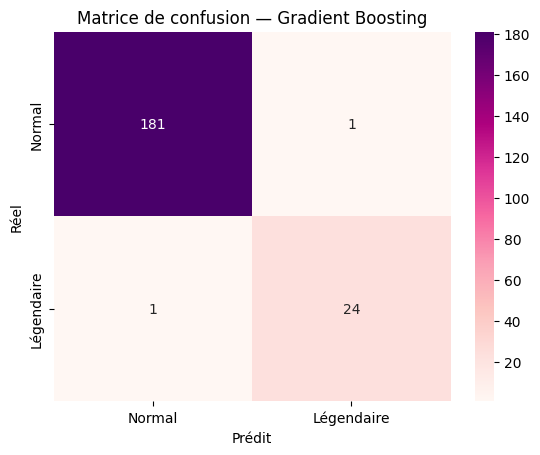

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       182
  Légendaire       0.96      0.96      0.96        25

    accuracy                           0.99       207
   macro avg       0.98      0.98      0.98       207
weighted avg       0.99      0.99      0.99       207

Meilleur score F1 (cross validation) : 0.9200179937022043


In [8]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Normal', 'Légendaire'],
            yticklabels=['Normal', 'Légendaire'])
plt.title("Matrice de confusion — Gradient Boosting")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.show()

# Rapport de classification
print(classification_report(y_test, y_pred, target_names=['Normal', 'Légendaire']))
print("Meilleur score F1 (cross validation) :", grid_search.best_score_)

...

### 4.2 Colonnes importantes

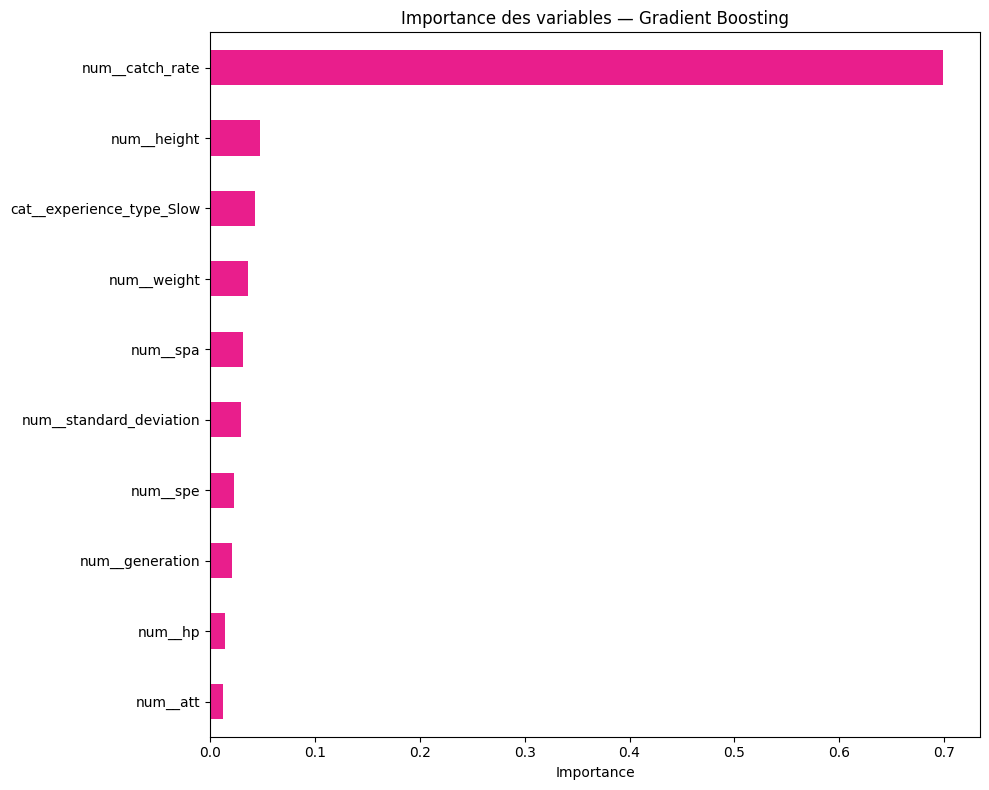

In [9]:
gb_model = gb_best.named_steps['gradientboostingclassifier']
feature_names = gb_best.named_steps['columntransformer'].get_feature_names_out()
importances = pd.Series(gb_model.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=True).tail(10)

importances.plot(kind='barh', color='#e91e8c', figsize=(10, 8))
plt.title("Importance des variables — Gradient Boosting")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()